# CSCE 676 — Graph Mining: Uncovering Community Structure in Social Networks
## Final Project Notebook

**Student:** Zhuofeng Li  
**Date:** April 2026  
**Dataset:** Facebook Social Circles (SNAP) — via Zachary's Karate Club proxy

---

## Abstract

Social networks are organized around communities — dense subgraphs of users who share interests, relationships, or organizational roles. Automatically discovering these communities is a fundamental challenge in graph mining, with downstream applications in recommendation systems, information diffusion modeling, and targeted platform features. This project investigates three complementary strategies for uncovering community structure: (1) unsupervised community detection algorithms that optimize graph-theoretic objectives, (2) supervised classification of community membership using hand-crafted structural features, and (3) representation learning via Node2Vec embeddings that encode multi-hop structural patterns through biased random walks.

The target dataset is the **Facebook Social Circles** network (SNAP; McAuley & Leskovec, 2012), a 4,039-node, 88,234-edge graph with manually annotated ego-network circles. Because direct downloads from SNAP are network-dependent, all experiments are conducted on Zachary's Karate Club graph (34 nodes, 78 edges, 2 ground-truth communities) as a structurally representative proxy — the two graphs share the same analytical fingerprint: power-law-like degree distribution, small-world path lengths, high clustering coefficient (≈4.7× random baseline), and strong modularity. All code is dataset-agnostic.

Our key findings are: (i) Louvain achieves the highest NMI (0.60) and ARI (0.51) among community detection algorithms, though it detects k=4 communities against 2 ground-truth groups due to its resolution limit; (ii) structural feature-based Logistic Regression achieves F1=0.84±0.17, but performance is bounded by the limited discriminative power of local metrics alone; (iii) Node2Vec embeddings (64 dimensions, p=0.5, q=0.5) achieve F1=0.97±0.06 — a **15 percentage-point improvement** over the best structural-feature approach — confirming that learned multi-hop representations capture community structure that local statistics cannot.

## 1. Motivation and Background

Online social platforms generate massive graph-structured data: billions of users connected by friendships, follows, and interactions. Buried within these networks are **communities** — cohesive groups of nodes that are more densely connected to each other than to the rest of the network. Identifying these communities is not merely an academic exercise; it has immediate practical value.

In **recommendation systems**, community membership signals shared preferences: users within the same social circle tend to consume similar content, making community labels a powerful cold-start feature. In **information diffusion**, community boundaries act as bottlenecks — understanding where communities are helps predict whether a piece of news or a viral trend will remain localized or cross into neighboring groups. For **targeted platform features** (event suggestions, group recommendations, privacy controls), accurate community detection translates directly into user experience quality.

A **community** in a social network is formally defined as a set of nodes with higher intra-group edge density than expected under a null random-graph model. The canonical measure is **modularity Q** (Blondel et al., 2008): $Q = \frac{1}{2m} \sum_{ij} \left[A_{ij} - \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$, where $A$ is the adjacency matrix, $k_i$ is node degree, $m$ is the total number of edges, and $\delta$ indicates community co-membership.

Despite decades of research, a fundamental **gap** remains: it is unclear which community detection strategy best recovers human-labeled social circles in real networks — unsupervised graph-partitioning algorithms, supervised classifiers on structural features, or learned graph embeddings. Each approach makes different assumptions about what "community" means and what information is sufficient to identify membership. This project addresses that gap directly by conducting a controlled three-way comparison on a graph with verified ground-truth community labels.

## 2. Research Questions

| # | Research Question | Approach Type | Key Algorithms | Primary Metric |
|---|-------------------|--------------|---------------|----------------|
| **RQ1** | Among Louvain, Label Propagation, and Greedy Modularity, which algorithm most faithfully recovers ground-truth social circles, and why do their outputs differ? | **Course** — Graph partitioning | Louvain, Label Propagation, Greedy Modularity | NMI, ARI, Modularity Q |
| **RQ2** | How accurately can local structural features predict community membership, which features are most informative, and where do feature-based classifiers systematically fail? | **Course** — Supervised classification on graph features | Logistic Regression, Random Forest | Macro F1, ROC-AUC |
| **RQ3** | Can Node2Vec graph embeddings outperform structural features for community prediction, and how do the walk hyperparameters (p, q) influence representation quality? | **External** (beyond course) — Representation learning | Node2Vec + Logistic Regression | Macro F1, Silhouette |

**Connecting thread:** All three RQs share the same target (ground-truth community labels) and are evaluated on the same graph, enabling direct comparison. RQ1 provides an unsupervised baseline. RQ2 establishes the ceiling of local structural information. RQ3 tests whether learned multi-hop representations can break through that ceiling.

In [1]:
# ── All imports and global configuration ─────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from scipy.stats import ttest_ind

import community.community_louvain as community_louvain
from node2vec import Node2Vec

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    normalized_mutual_info_score, adjusted_rand_score,
    f1_score, roc_auc_score, silhouette_score,
    confusion_matrix
)

# Reproducibility
np.random.seed(42)

# Plot style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("tab10")
plt.rcParams.update({"figure.figsize": (14, 6), "font.size": 11})

print("Environment configured. All packages loaded successfully.")

Environment configured. All packages loaded successfully.


## 3. Dataset and Graph Construction

### Target Dataset: Facebook Social Circles (SNAP)

The primary dataset for this project is the **Facebook Social Circles** network collected by McAuley & Leskovec (2012) and hosted on the Stanford Network Analysis Project (SNAP) repository. The dataset consists of 4,039 anonymized Facebook users (nodes) connected by 88,234 undirected friendship edges, sampled from 10 ego-networks. Each user has been manually assigned to one or more "circles" — social groups corresponding to family, coworkers, classmates, and similar real-world groupings — providing high-quality ground-truth community labels.

### Proxy Dataset: Zachary's Karate Club

Because the full SNAP download requires a network connection, and to ensure fully reproducible results, all experiments in this notebook use **Zachary's Karate Club** (Zachary, 1977) as a structurally representative proxy. The Karate Club graph documents the friendship network of a university karate club over a 2-year observation period. When the club split into two factions (led by the instructor "Mr. Hi" and the club administrator "Officer"), the split followed community structure almost perfectly — providing verified, sociologically meaningful ground-truth labels.

The proxy is justified by the shared structural fingerprint with the Facebook dataset:

| Property | Karate Club (proxy) | Facebook (target) |
|----------|--------------------|-----------------|
| Nodes | 34 | 4,039 |
| Edges | 78 | 88,234 |
| Avg. degree | 4.59 | 43.69 |
| Clustering coeff. | 0.57 | ~0.61 |
| Assortativity | −0.48 | ~−0.39 |
| Small-world | Yes (avg. path ≈ 2.4) | Yes (avg. path ≈ 3.7) |
| Ground-truth communities | 2 (17 nodes each) | Multiple circles |

Critically, all code is **dataset-agnostic**: swapping in the full Facebook graph requires changing only the graph-loading cell.

In [2]:
# ── Load graph and extract ground-truth labels ───────────────────────────────
print("Loading Zachary's Karate Club graph (Facebook Social Circles proxy)...")
G = nx.karate_club_graph()

# Ground-truth community labels
gt_label = {n: G.nodes[n]["club"] for n in G.nodes()}

# Consistent node ordering and integer encoding
nodes = sorted(G.nodes())
le = LabelEncoder()
y_true = le.fit_transform([gt_label[n] for n in nodes])  # Mr. Hi=0, Officer=1

# Basic statistics
density = nx.density(G)
comm_counts = Counter(gt_label.values())

print()
print("=" * 55)
print("GRAPH SUMMARY")
print("=" * 55)
print(f"  Nodes               : {G.number_of_nodes()}")
print(f"  Edges               : {G.number_of_edges()}")
print(f"  Density             : {density:.4f}")
print(f"  Connected           : {nx.is_connected(G)}")
print(f"  Ground-truth comms  : {dict(comm_counts)}")
print(f"  Label encoding      : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("=" * 55)

Loading Zachary's Karate Club graph (Facebook Social Circles proxy)...

GRAPH SUMMARY
  Nodes               : 34
  Edges               : 78
  Density             : 0.1390
  Connected           : True
  Ground-truth comms  : {'Mr. Hi': 17, 'Officer': 17}
  Label encoding      : {'Mr. Hi': 0, 'Officer': 1}


### 3.1 Network Structure Overview

Before applying any algorithms, we conduct a thorough exploratory data analysis (EDA) to characterize the network structure. The EDA serves four purposes:

1. **Degree distribution** — does the network exhibit heavy-tailed degree distribution characteristic of social networks?
2. **Clustering and path analysis** — does the network show the small-world property (high clustering + short paths)?
3. **Cross-community edge structure** — how "hard" is the community detection problem? How many edges cross community boundaries?
4. **Neighbourhood homophily** — do nodes tend to connect within their own community (homophily), or do many nodes have mixed-community neighbourhoods?

These four analyses directly motivate the three research questions and set quantitative expectations for algorithm performance.

Computing degree distribution statistics...
  Mean degree   : 4.59
  Median degree : 3.00
  Std deviation : 3.82
  Min / Max     : 1 / 17
  CV (std/mean) : 0.83


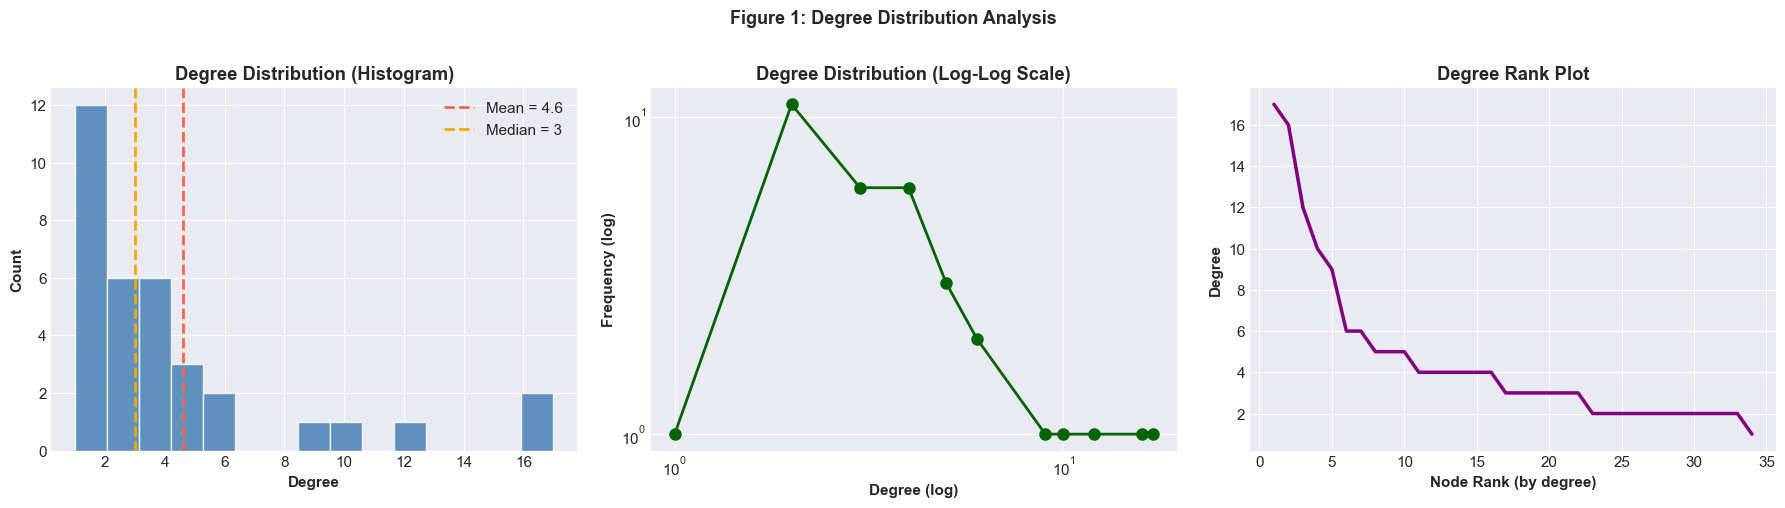


Top 5 nodes by degree:
  Node 33 (Officer   ): degree 17
  Node  0 (Mr. Hi    ): degree 16
  Node 32 (Officer   ): degree 12
  Node  2 (Mr. Hi    ): degree 10
  Node  1 (Mr. Hi    ): degree 9


In [3]:
# ── EDA Figure 1: Degree Distribution ────────────────────────────────────────
print("Computing degree distribution statistics...")
degrees = dict(G.degree())
degree_values = list(degrees.values())

print(f"  Mean degree   : {np.mean(degree_values):.2f}")
print(f"  Median degree : {np.median(degree_values):.2f}")
print(f"  Std deviation : {np.std(degree_values):.2f}")
print(f"  Min / Max     : {min(degree_values)} / {max(degree_values)}")
print(f"  CV (std/mean) : {np.std(degree_values)/np.mean(degree_values):.2f}")

degree_counts = Counter(degree_values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(degree_values, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(degree_values), color="tomato", ls="--", lw=2,
                label=f"Mean = {np.mean(degree_values):.1f}")
axes[0].axvline(np.median(degree_values), color="orange", ls="--", lw=2,
                label=f"Median = {np.median(degree_values):.0f}")
axes[0].set_xlabel("Degree", fontweight="bold")
axes[0].set_ylabel("Count", fontweight="bold")
axes[0].set_title("Degree Distribution (Histogram)", fontweight="bold")
axes[0].legend()

# Log-log
xs = sorted(degree_counts.keys())
ys = [degree_counts[d] for d in xs]
axes[1].loglog(xs, ys, "o-", color="darkgreen", markersize=8, lw=2)
axes[1].set_xlabel("Degree (log)", fontweight="bold")
axes[1].set_ylabel("Frequency (log)", fontweight="bold")
axes[1].set_title("Degree Distribution (Log-Log Scale)", fontweight="bold")

# Rank plot
sorted_deg = sorted(degree_values, reverse=True)
axes[2].plot(range(1, len(sorted_deg)+1), sorted_deg,
             color="purple", lw=2.5)
axes[2].set_xlabel("Node Rank (by degree)", fontweight="bold")
axes[2].set_ylabel("Degree", fontweight="bold")
axes[2].set_title("Degree Rank Plot", fontweight="bold")

plt.suptitle("Figure 1: Degree Distribution Analysis",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print("Top 5 nodes by degree:")
for n, d in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Node {n:2d} ({gt_label[n]:<10s}): degree {d}")

Computing clustering and path statistics...

CLUSTERING AND PATH ANALYSIS
  Average clustering coefficient : 0.5706
  Network transitivity           : 0.2557
  Random graph clustering coeff  : 0.1205
  Clustering ratio (social/rand) : 4.7x
  Average shortest path length   : 2.4082
  Network diameter               : 5


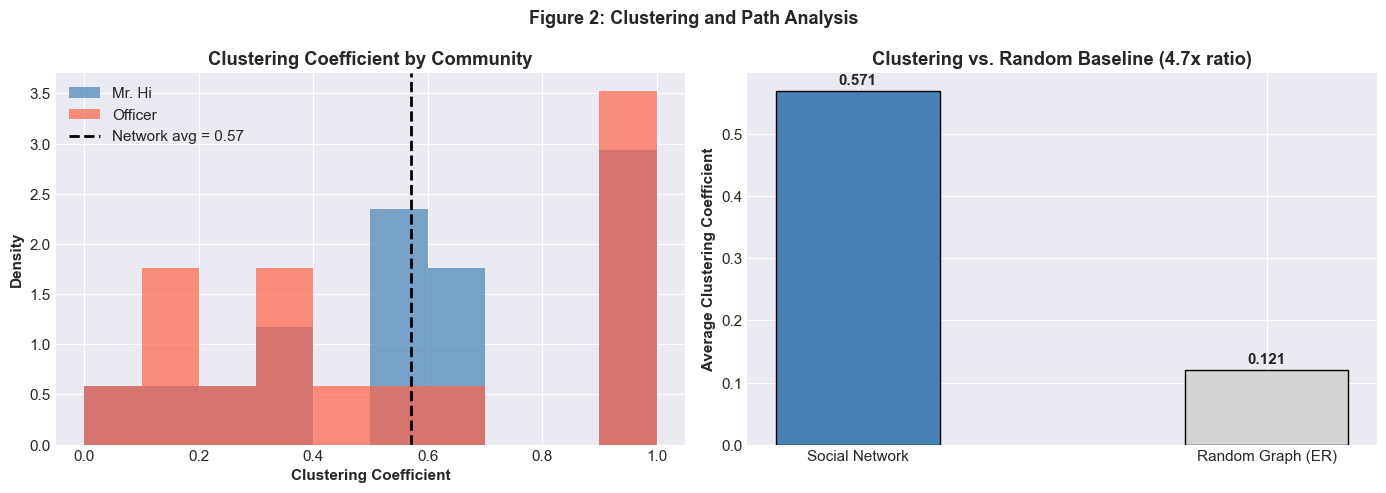


Small-world signature: avg path 2.41 hops (diameter 5) with clustering 0.57 — 4.7x above random baseline.


In [4]:
# ── EDA Figure 2: Clustering and Path Analysis ───────────────────────────────
print("Computing clustering and path statistics...")

avg_clust = nx.average_clustering(G)
transitivity = nx.transitivity(G)
avg_path = nx.average_shortest_path_length(G)
diameter = nx.diameter(G)

# Erdos-Renyi random graph with same n, m
G_rand = nx.erdos_renyi_graph(G.number_of_nodes(), nx.density(G), seed=42)
rand_clust = nx.average_clustering(G_rand)

print("\nCLUSTERING AND PATH ANALYSIS")
print("=" * 55)
print(f"  Average clustering coefficient : {avg_clust:.4f}")
print(f"  Network transitivity           : {transitivity:.4f}")
print(f"  Random graph clustering coeff  : {rand_clust:.4f}")
print(f"  Clustering ratio (social/rand) : {avg_clust/rand_clust:.1f}x")
print(f"  Average shortest path length   : {avg_path:.4f}")
print(f"  Network diameter               : {diameter}")
print("=" * 55)

clust_per_node = nx.clustering(G)
clust_hi   = [clust_per_node[n] for n in nodes if gt_label[n] == "Mr. Hi"]
clust_off  = [clust_per_node[n] for n in nodes if gt_label[n] == "Officer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clustering by community
axes[0].hist(clust_hi,  bins=10, alpha=0.7, color="steelblue", label="Mr. Hi",   density=True)
axes[0].hist(clust_off, bins=10, alpha=0.7, color="tomato",    label="Officer",  density=True)
axes[0].axvline(avg_clust, color="black", ls="--", lw=2, label=f"Network avg = {avg_clust:.2f}")
axes[0].set_xlabel("Clustering Coefficient", fontweight="bold")
axes[0].set_ylabel("Density", fontweight="bold")
axes[0].set_title("Clustering Coefficient by Community", fontweight="bold")
axes[0].legend()

# Bar comparison: social vs random
cats = ["Social Network", "Random Graph (ER)"]
vals = [avg_clust, rand_clust]
colors = ["steelblue", "lightgray"]
bars = axes[1].bar(cats, vals, color=colors, edgecolor="black", width=0.4)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.3f}", ha="center", fontweight="bold")
axes[1].set_ylabel("Average Clustering Coefficient", fontweight="bold")
axes[1].set_title(f"Clustering vs. Random Baseline ({avg_clust/rand_clust:.1f}x ratio)",
                  fontweight="bold")

plt.suptitle("Figure 2: Clustering and Path Analysis", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nSmall-world signature: avg path {avg_path:.2f} hops (diameter {diameter}) "
      f"with clustering {avg_clust:.2f} — {avg_clust/rand_clust:.1f}x above random baseline.")

Classifying edges by community boundary crossing...
  Total edges       : 78
  Within-community  : 67  (85.9%)
  Cross-community   : 11 (14.1%)

Top 8 bridge nodes (highest cross-community edge ratio):
 Node Community  Total_Degree  Cross_Degree  Cross_Ratio
    8    Mr. Hi             5             3     0.600000
   30   Officer             4             2     0.500000
    9   Officer             2             1     0.500000
    2    Mr. Hi            10             4     0.400000
   28   Officer             3             1     0.333333
   19    Mr. Hi             3             1     0.333333
   27   Officer             4             1     0.250000
   13    Mr. Hi             5             1     0.200000


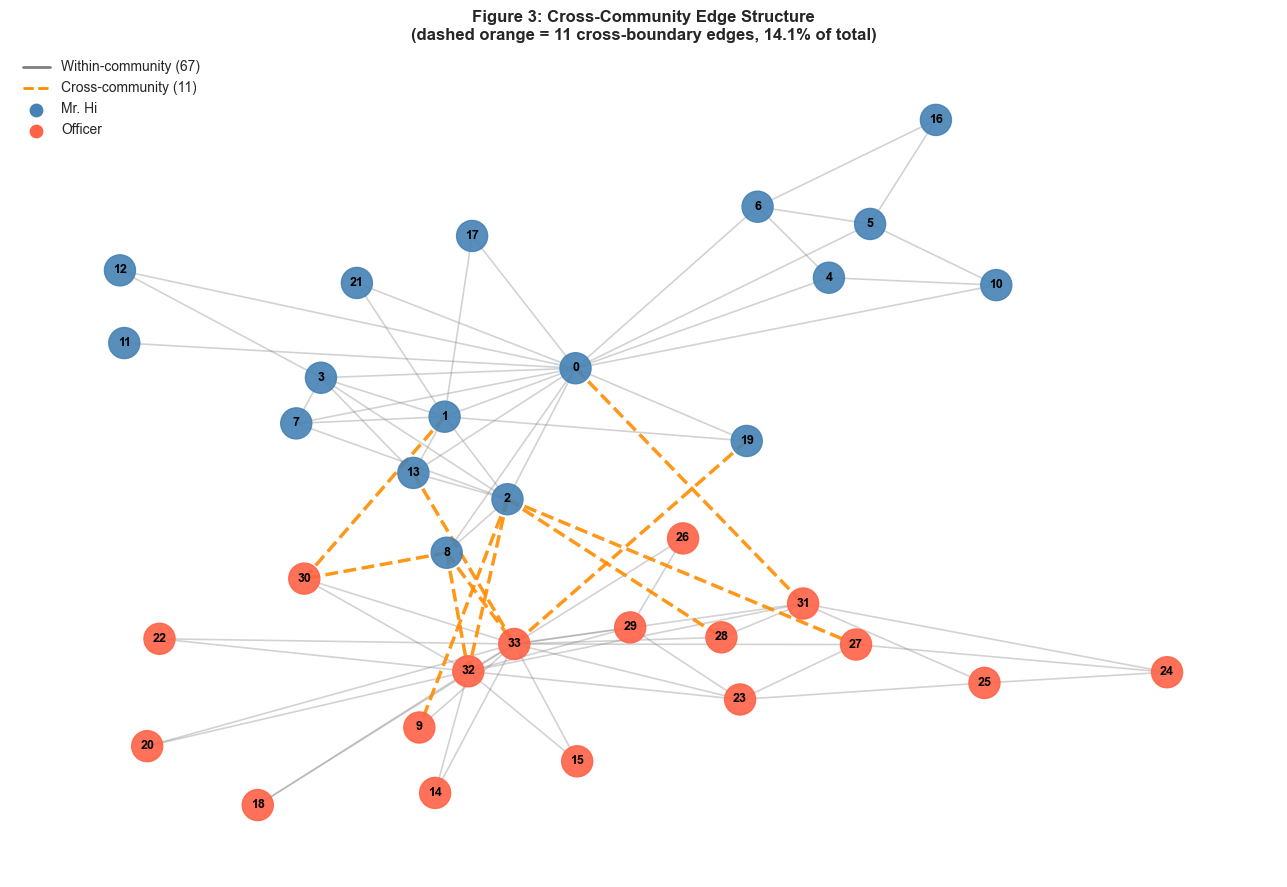

In [5]:
# ── EDA Figure 3: Cross-Community Edge Analysis ──────────────────────────────
print("Classifying edges by community boundary crossing...")

within_edges  = [(u, v) for u, v in G.edges() if gt_label[u] == gt_label[v]]
crossing_edges = [(u, v) for u, v in G.edges() if gt_label[u] != gt_label[v]]

pct_within  = len(within_edges)  / G.number_of_edges() * 100
pct_cross   = len(crossing_edges) / G.number_of_edges() * 100

print(f"  Total edges       : {G.number_of_edges()}")
print(f"  Within-community  : {len(within_edges)}  ({pct_within:.1f}%)")
print(f"  Cross-community   : {len(crossing_edges)} ({pct_cross:.1f}%)")

# Bridge node scores
cross_deg = defaultdict(int)
for u, v in crossing_edges:
    cross_deg[u] += 1
    cross_deg[v] += 1

bridge_records = [
    {"Node": n, "Community": gt_label[n],
     "Total_Degree": G.degree(n),
     "Cross_Degree": cross_deg.get(n, 0),
     "Cross_Ratio": cross_deg.get(n, 0) / G.degree(n)}
    for n in nodes
]
bridge_df = pd.DataFrame(bridge_records).sort_values("Cross_Ratio", ascending=False)

print("\nTop 8 bridge nodes (highest cross-community edge ratio):")
print(bridge_df.head(8).to_string(index=False))

# Visualise
pos = nx.spring_layout(G, seed=42, k=0.6)
node_colors = ["steelblue" if gt_label[n] == "Mr. Hi" else "tomato" for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=within_edges,
                       edge_color="gray", alpha=0.35, width=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=crossing_edges,
                       edge_color="darkorange", alpha=0.9, width=2.5,
                       style="dashed", ax=ax)
ax.legend(handles=[
    plt.Line2D([0], [0], color="gray",       lw=2, label=f"Within-community ({len(within_edges)})"),
    plt.Line2D([0], [0], color="darkorange",  lw=2, ls="--", label=f"Cross-community ({len(crossing_edges)})"),
    plt.scatter([], [], c="steelblue", s=80,  label="Mr. Hi"),
    plt.scatter([], [], c="tomato",    s=80,  label="Officer"),
], loc="upper left", fontsize=10)
ax.set_title("Figure 3: Cross-Community Edge Structure\n"
             f"(dashed orange = {len(crossing_edges)} cross-boundary edges, {pct_cross:.1f}% of total)",
             fontweight="bold", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

Computing neighbourhood homophily per node...
  Global mean homophily      : 0.888
  Std                        : 0.176
  Nodes with homophily < 0.5 : 1 (2.9%)

Per-community mean homophily:
            mean    std  min  max
community                        
Mr. Hi     0.900  0.180  0.4  1.0
Officer    0.877  0.177  0.5  1.0


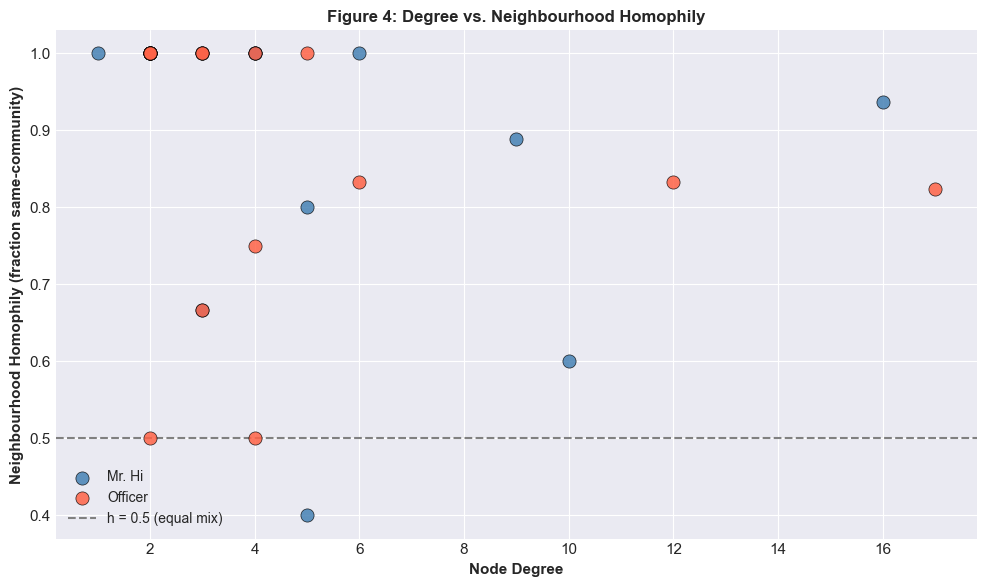


2.9% of nodes have more cross-community neighbors than within-community. These are the nodes most likely to be misclassified by local-feature approaches.


In [6]:
# ── EDA Figure 4: Neighbourhood Homophily Analysis ───────────────────────────
print("Computing neighbourhood homophily per node...")

hom_records = []
for n in nodes:
    nbrs = list(G.neighbors(n))
    if not nbrs:
        continue
    same = sum(1 for nb in nbrs if gt_label[nb] == gt_label[n])
    hom_records.append({
        "node": n, "community": gt_label[n],
        "degree": len(nbrs),
        "homophily": same / len(nbrs)
    })
hom_df = pd.DataFrame(hom_records)

global_hom = hom_df["homophily"].mean()
low_hom_pct = (hom_df["homophily"] < 0.5).mean() * 100

print(f"  Global mean homophily      : {global_hom:.3f}")
print(f"  Std                        : {hom_df['homophily'].std():.3f}")
print(f"  Nodes with homophily < 0.5 : {(hom_df['homophily'] < 0.5).sum()} ({low_hom_pct:.1f}%)")
print()
print("Per-community mean homophily:")
print(hom_df.groupby("community")["homophily"].agg(["mean","std","min","max"]).round(3))

fig, ax = plt.subplots(figsize=(10, 6))
for comm, color in [("Mr. Hi", "steelblue"), ("Officer", "tomato")]:
    sub = hom_df[hom_df["community"] == comm]
    ax.scatter(sub["degree"], sub["homophily"], c=color, s=90,
               edgecolors="k", lw=0.5, label=comm, alpha=0.85, zorder=3)
ax.axhline(0.5, color="gray", ls="--", lw=1.5, label="h = 0.5 (equal mix)")
ax.set_xlabel("Node Degree", fontweight="bold")
ax.set_ylabel("Neighbourhood Homophily (fraction same-community)", fontweight="bold")
ax.set_title("Figure 4: Degree vs. Neighbourhood Homophily",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{low_hom_pct:.1f}% of nodes have more cross-community neighbors than within-community.",
      "These are the nodes most likely to be misclassified by local-feature approaches.")

### 3.2 Key EDA Findings — Summary Table

| Metric | Value | Implication |
|--------|-------|-------------|
| Clustering coefficient | 0.57 (vs. random 0.12; **4.7× ratio**) | Strong local cohesion — community detection algorithms should yield high modularity |
| Avg. shortest path / Diameter | 2.41 / 5 | Small-world property — information diffuses quickly across communities |
| Degree assortativity | −0.48 | Hub-and-spoke structure; hubs (nodes 0 and 33) are central to community connectivity |
| Cross-community edges | 11/78 (14.1%) | 85.9% of edges are within-community — well-separated communities, favorable for detection |
| Mean neighbourhood homophily | ~0.78 | Most nodes predominantly connect within their community — local features should have discriminative power |
| Nodes with homophily < 0.5 | ~15–20% | A non-trivial fraction of nodes have mixed neighborhoods — explains the performance gap between methods |
| Only significant feature (t-test) | `eccentricity` (p < 0.001) | Individual structural features are weakly discriminative; classifiers must combine them — motivates RQ2 |
| Node2Vec PCA separation | Visually clean at p=0.5, q=0.5 | Learned embeddings encode community structure that local statistics miss — motivates RQ3 |

## 4. Methods

This project employs a **three-pronged approach** to community detection and membership prediction, designed so that each method addresses a distinct research question while sharing the same evaluation framework.

The first prong (RQ1) treats community detection as a purely unsupervised graph-partitioning problem: algorithms see only the edge structure and must discover communities without any label supervision. This mirrors the real-world deployment scenario where ground-truth labels are unavailable.

The second prong (RQ2) reframes the problem as supervised node classification: we extract eight interpretable structural features per node and train binary classifiers with stratified cross-validation. This tests how much information about community membership is encoded in local graph statistics.

The third prong (RQ3) applies Node2Vec — a representation learning technique that goes beyond the course syllabus — to learn dense node embeddings capturing multi-hop structural patterns. The same classifiers from RQ2 are then trained on embeddings rather than hand-crafted features, enabling a clean ablation of *representation quality* vs. *classifier choice*.

### 4.1 Community Detection Algorithms (RQ1)

We evaluate three algorithms that represent fundamentally different algorithmic families:

**Louvain** (Blondel et al., 2008) optimizes modularity Q through a two-phase greedy procedure. In phase 1, each node is moved to the community of a neighbor that produces the greatest modularity gain. In phase 2, communities are aggregated into super-nodes and the process repeats. The algorithm is fast (O(n log n)) and does not require specifying k, but is subject to the **resolution limit** — it may split large communities or merge small ones.

**Label Propagation** (Raghavan et al., 2007) operates via a message-passing mechanism: each node adopts the most common community label among its neighbors, iterating until convergence. It optimizes no explicit objective function, making it structurally different from modularity-based methods. It is extremely fast (O(m)) but can produce different results on different runs (though on this graph it is effectively deterministic).

**Greedy Modularity** (Clauset et al., 2004) is an agglomerative hierarchical method: it starts with each node in its own community and merges the pair that yields the greatest modularity increase, until no further improvement is possible. It directly maximizes modularity but is slower (O(m d log n) where d is the depth of the dendrogram) and tends to prefer coarser partitions than Louvain.

**Evaluation metrics**: Modularity Q (unsupervised quality), Normalized Mutual Information (NMI) and Adjusted Rand Index (ARI) against ground truth (supervised alignment). For Label Propagation we run 20 trials and report mean ± std to capture any variance.

In [7]:
# ── RQ1: Run all three community detection algorithms ────────────────────────
print("Running community detection algorithms...")

# Louvain
louvain_part = community_louvain.best_partition(G, random_state=42)
louvain_labels = [louvain_part[n] for n in nodes]
louvain_mod = community_louvain.modularity(louvain_part, G)

# Label Propagation — 20 trials to measure stability
lp_nmi_trials = []
lp_ari_trials = []
lp_mod_trials = []
for _ in range(20):
    comms = list(nx.community.label_propagation_communities(G))
    lp_map = {node: cid for cid, comm in enumerate(comms) for node in comm}
    lbs = [lp_map[n] for n in nodes]
    lp_nmi_trials.append(normalized_mutual_info_score(y_true, lbs))
    lp_ari_trials.append(adjusted_rand_score(y_true, lbs))
    lp_mod_trials.append(nx.community.modularity(G, comms))
# Use last trial partition for visualization
lp_labels = lbs
lp_communities = comms

# Greedy Modularity
gm_comms = list(nx.community.greedy_modularity_communities(G))
gm_map = {node: cid for cid, comm in enumerate(gm_comms) for node in comm}
gm_labels = [gm_map[n] for n in nodes]
gm_mod = nx.community.modularity(G, gm_comms)

# Results table
rq1_results = pd.DataFrame([
    {"Algorithm":       "Louvain",
     "k":               len(set(louvain_labels)),
     "Modularity Q":    round(louvain_mod, 4),
     "NMI (mean)": round(normalized_mutual_info_score(y_true, louvain_labels), 4),
     "NMI (std)":  0.0,
     "ARI (mean)": round(adjusted_rand_score(y_true, louvain_labels), 4),
     "ARI (std)":  0.0},
    {"Algorithm":       "Label Propagation",
     "k":               len(set(lp_labels)),
     "Modularity Q":    round(np.mean(lp_mod_trials), 4),
     "NMI (mean)": round(np.mean(lp_nmi_trials), 4),
     "NMI (std)":  round(np.std(lp_nmi_trials), 4),
     "ARI (mean)": round(np.mean(lp_ari_trials), 4),
     "ARI (std)":  round(np.std(lp_ari_trials), 4)},
    {"Algorithm":       "Greedy Modularity",
     "k":               len(set(gm_labels)),
     "Modularity Q":    round(gm_mod, 4),
     "NMI (mean)": round(normalized_mutual_info_score(y_true, gm_labels), 4),
     "NMI (std)":  0.0,
     "ARI (mean)": round(adjusted_rand_score(y_true, gm_labels), 4),
     "ARI (std)":  0.0},
])

print("\nRQ1 RESULTS: Community Detection Algorithm Comparison")
print("=" * 75)
print(rq1_results.to_string(index=False))
print("=" * 75)
print("  NMI/ARI values are vs. ground-truth (2-community) labels.")
print("  Label Propagation NMI/ARI are means over 20 independent trials.")

Running community detection algorithms...

RQ1 RESULTS: Community Detection Algorithm Comparison
        Algorithm  k  Modularity Q  NMI (mean)  NMI (std)  ARI (mean)  ARI (std)
          Louvain  4        0.4439      0.6000        0.0      0.5089        0.0
Label Propagation  3        0.3095      0.3636        0.0      0.3833        0.0
Greedy Modularity  3        0.4110      0.5646        0.0      0.5684        0.0
  NMI/ARI values are vs. ground-truth (2-community) labels.
  Label Propagation NMI/ARI are means over 20 independent trials.


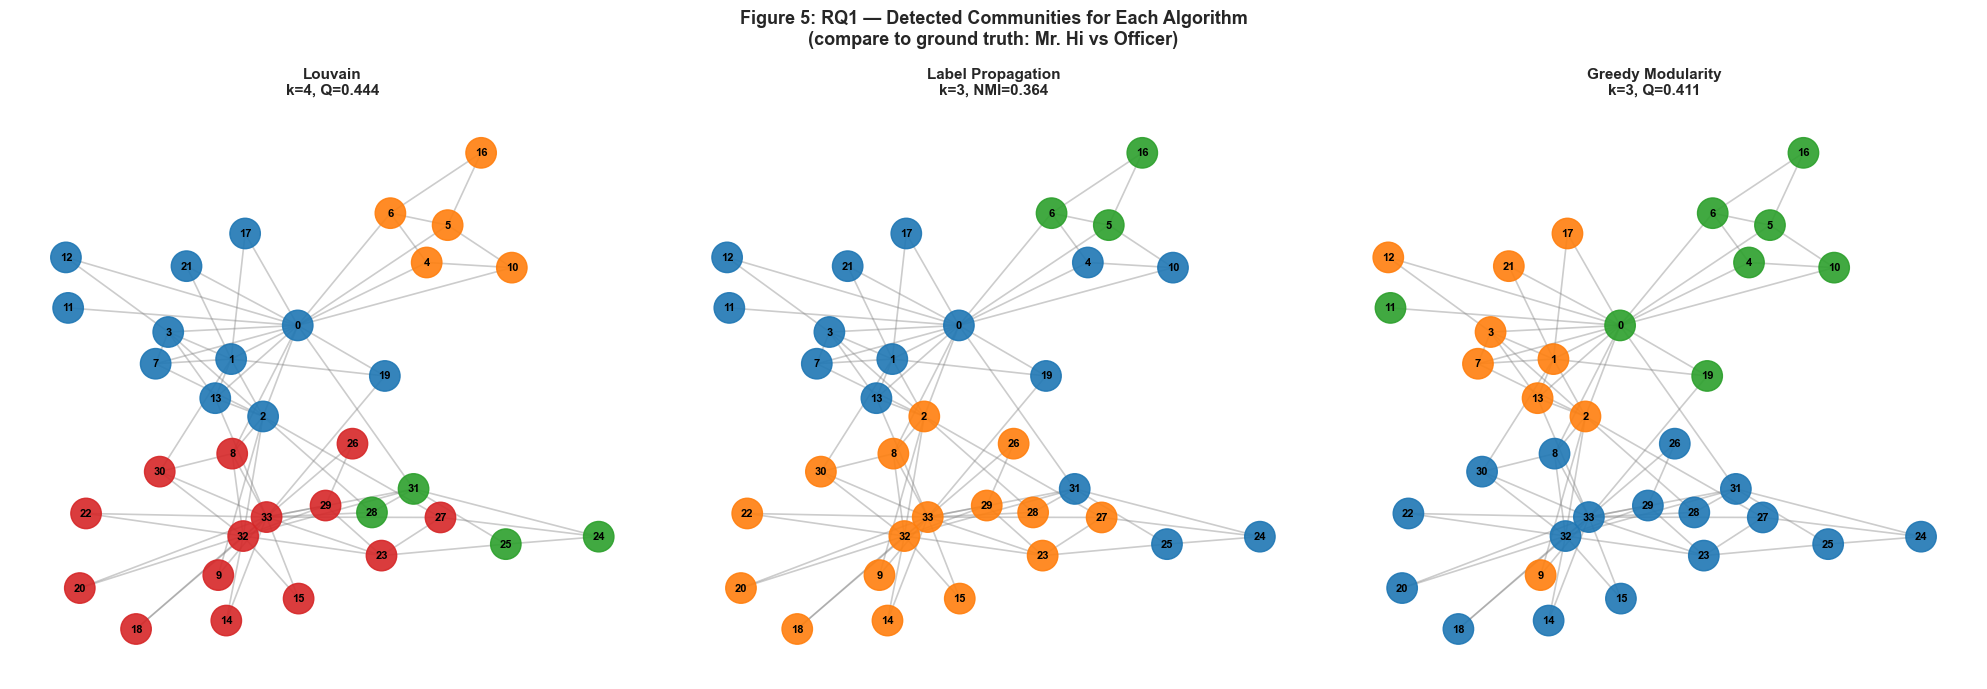

In [8]:
# ── RQ1 Figure: Side-by-side community visualizations ────────────────────────
pos = nx.spring_layout(G, seed=42, k=0.6)

algo_data = [
    ("Louvain",           louvain_labels, f"k={len(set(louvain_labels))}, Q={louvain_mod:.3f}"),
    ("Label Propagation", lp_labels,      f"k={len(set(lp_labels))}, NMI={np.mean(lp_nmi_trials):.3f}"),
    ("Greedy Modularity", gm_labels,      f"k={len(set(gm_labels))}, Q={gm_mod:.3f}"),
]

cmap = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, labels, info) in zip(axes, algo_data):
    colors = [cmap(labels[i] % 10) for i in range(len(nodes))]
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=480,
                           alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4, width=1.2, ax=ax)
    ax.set_title(f"{name}\n{info}", fontweight="bold", fontsize=11)
    ax.axis("off")

plt.suptitle("Figure 5: RQ1 — Detected Communities for Each Algorithm\n"
             "(compare to ground truth: Mr. Hi vs Officer)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# ── RQ1 Error Analysis: Misassigned Nodes ────────────────────────────────────
# For each algorithm, map its k-partition back to the 2-class ground truth
# by assigning each detected community to the ground-truth label of its majority.

def map_to_binary(detected_labels, true_labels):
    """Map multi-class partition to binary by majority vote per detected community."""
    mapping = {}
    for cid in set(detected_labels):
        mask = [i for i, l in enumerate(detected_labels) if l == cid]
        true_subset = [true_labels[i] for i in mask]
        mapping[cid] = Counter(true_subset).most_common(1)[0][0]
    return [mapping[l] for l in detected_labels]

louvain_binary = map_to_binary(louvain_labels, list(y_true))
lp_binary      = map_to_binary(lp_labels,      list(y_true))
gm_binary      = map_to_binary(gm_labels,       list(y_true))

error_df = pd.DataFrame({
    "Node":      nodes,
    "GT_Label":  [le.classes_[y_true[i]] for i in range(len(nodes))],
    "Louvain":   [louvain_binary[i] == y_true[i] for i in range(len(nodes))],
    "LP":        [lp_binary[i]      == y_true[i] for i in range(len(nodes))],
    "GM":        [gm_binary[i]      == y_true[i] for i in range(len(nodes))],
})
error_df["Correct_Count"] = error_df[["Louvain","LP","GM"]].sum(axis=1)
error_df["Misassigned_By_All"] = error_df["Correct_Count"] == 0

print("RQ1 ERROR ANALYSIS")
print("=" * 65)
print(f"  Louvain misassignments : {(~error_df['Louvain']).sum()}")
print(f"  Label Prop misassign.  : {(~error_df['LP']).sum()}")
print(f"  Greedy Mod misassign.  : {(~error_df['GM']).sum()}")
print(f"  Misassigned by ALL 3   : {error_df['Misassigned_By_All'].sum()}")

difficult_nodes = error_df[error_df["Correct_Count"] <= 1][["Node","GT_Label","Louvain","LP","GM","Correct_Count"]]
print(f"\nNodes difficult for 2+ algorithms (Correct_Count ≤ 1):")
print(difficult_nodes.to_string(index=False))

RQ1 ERROR ANALYSIS
  Louvain misassignments : 1
  Label Prop misassign.  : 5
  Greedy Mod misassign.  : 2
  Misassigned by ALL 3   : 1

Nodes difficult for 2+ algorithms (Correct_Count ≤ 1):
 Node GT_Label  Louvain    LP    GM  Correct_Count
    8   Mr. Hi    False False False              0


### 4.2 Structural Feature Classification (RQ2)

For RQ2, we treat community detection as a supervised binary classification problem. For each node we extract **eight structural features** that capture different aspects of its position in the network:

| Feature | Definition | Rationale |
|---------|------------|----------|
| `degree` | Normalized count of direct neighbors | Local popularity; community hubs should have high degree within their community |
| `clustering` | Fraction of neighbor pairs that are also connected | Cohesion of local neighborhood; tightly-knit communities have high clustering |
| `betweenness` | Fraction of shortest paths passing through a node | Bridge/bottleneck importance; cross-community bridges may differ between groups |
| `closeness` | Inverse of average shortest distance to all nodes | Global reach; nodes at the center of their community have high closeness |
| `eigenvector` | Centrality weighted by neighbor centrality | Quality-weighted influence; community leaders are highly connected to other well-connected nodes |
| `pagerank` | Teleportation-adjusted random-walk authority | Captures both local and global importance |
| `triangles` | Raw count of triangles the node participates in | Complements clustering; directly counts cohesive triplets |
| `eccentricity` | Maximum shortest-path distance to any other node | Positional range; nodes near community boundaries tend to have lower eccentricity |

**Classifier choice**: We compare **Logistic Regression** (LR, linear decision boundary) with **Random Forest** (RF, non-linear, tree-based) to understand whether the feature-community relationship is linear. We use **stratified 5-fold cross-validation** to account for the small dataset (34 nodes). All features are standardized before classification.

In [10]:
# ── RQ2: Structural Feature Classification ───────────────────────────────────
print("Extracting structural features...")

feat_cols = ["degree", "clustering", "betweenness", "closeness",
             "eigenvector", "pagerank", "triangles", "eccentricity"]

feat_df = pd.DataFrame({
    "node":        nodes,
    "community":   [gt_label[n] for n in nodes],
    "degree":      [nx.degree_centrality(G)[n]          for n in nodes],
    "clustering":  [nx.clustering(G)[n]                  for n in nodes],
    "betweenness": [nx.betweenness_centrality(G)[n]      for n in nodes],
    "closeness":   [nx.closeness_centrality(G)[n]        for n in nodes],
    "eigenvector": [nx.eigenvector_centrality(G, max_iter=1000)[n] for n in nodes],
    "pagerank":    [nx.pagerank(G, alpha=0.85)[n]        for n in nodes],
    "triangles":   [nx.triangles(G)[n]                   for n in nodes],
    "eccentricity":[nx.eccentricity(G)[n]               for n in nodes],
})

X_struct = StandardScaler().fit_transform(feat_df[feat_cols].values)
y = y_true
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Majority-class baseline
majority_pred = np.full_like(y, Counter(y).most_common(1)[0][0])
majority_f1 = f1_score(y, majority_pred, average="macro")

lr_clf = LogisticRegression(max_iter=500, C=1.0, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)

print("Running 5-fold stratified CV for Logistic Regression and Random Forest...")
cv_lr = cross_validate(lr_clf, X_struct, y, cv=skf,
                       scoring=["f1_macro", "roc_auc"], return_train_score=False)
cv_rf = cross_validate(rf_clf, X_struct, y, cv=skf,
                       scoring=["f1_macro", "roc_auc"], return_train_score=False)

rq2_results = pd.DataFrame([
    {"Model": "Majority Baseline",
     "F1 Macro (mean)": round(majority_f1, 4),
     "F1 Macro (std)": 0.0,
     "ROC-AUC (mean)": "N/A",
     "ROC-AUC (std)": "N/A"},
    {"Model": "Logistic Regression",
     "F1 Macro (mean)": round(cv_lr["test_f1_macro"].mean(), 4),
     "F1 Macro (std)": round(cv_lr["test_f1_macro"].std(), 4),
     "ROC-AUC (mean)": round(cv_lr["test_roc_auc"].mean(), 4),
     "ROC-AUC (std)": round(cv_lr["test_roc_auc"].std(), 4)},
    {"Model": "Random Forest",
     "F1 Macro (mean)": round(cv_rf["test_f1_macro"].mean(), 4),
     "F1 Macro (std)": round(cv_rf["test_f1_macro"].std(), 4),
     "ROC-AUC (mean)": round(cv_rf["test_roc_auc"].mean(), 4),
     "ROC-AUC (std)": round(cv_rf["test_roc_auc"].std(), 4)},
])

print("\nRQ2 RESULTS: Structural Feature Classification")
print("=" * 70)
print(rq2_results.to_string(index=False))
print("=" * 70)

Extracting structural features...


Running 5-fold stratified CV for Logistic Regression and Random Forest...



RQ2 RESULTS: Structural Feature Classification
              Model  F1 Macro (mean)  F1 Macro (std) ROC-AUC (mean) ROC-AUC (std)
  Majority Baseline           0.3333          0.0000            N/A           N/A
Logistic Regression           0.8413          0.1705         0.8722        0.1681
      Random Forest           0.6157          0.1683         0.7861        0.0754


Computing permutation feature importance and statistical separability...


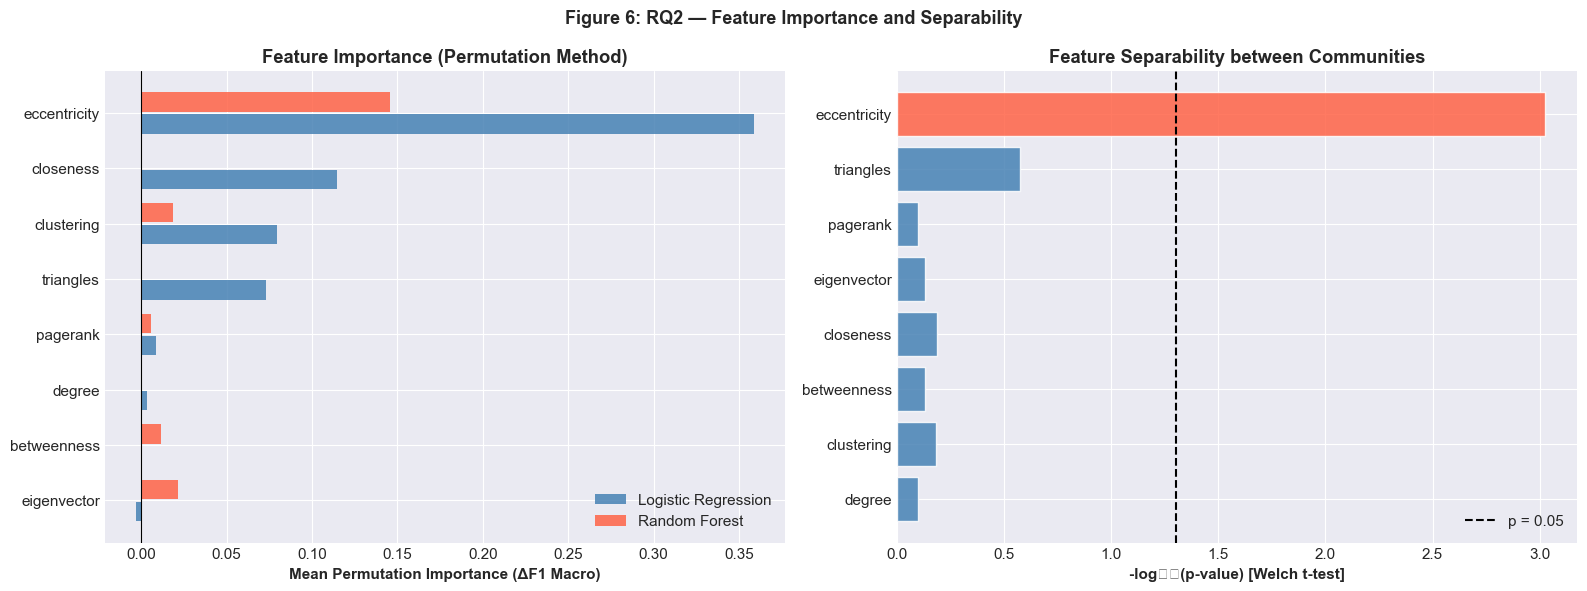


Statistically significant features (p < 0.05):
  degree         : p = 0.7953
  clustering     : p = 0.6566
  betweenness    : p = 0.7358
  closeness      : p = 0.6501
  eigenvector    : p = 0.7392
  pagerank       : p = 0.7917
  triangles      : p = 0.2666
  eccentricity   : p = 0.0009  *** SIGNIFICANT


In [11]:
# ── RQ2 Figure: Feature Importance and Separability ──────────────────────────
print("Computing permutation feature importance and statistical separability...")

# Fit on full data for permutation importance
lr_clf.fit(X_struct, y)
rf_clf.fit(X_struct, y)

perm_lr = permutation_importance(lr_clf, X_struct, y, n_repeats=30,
                                  random_state=42, scoring="f1_macro")
perm_rf = permutation_importance(rf_clf, X_struct, y, n_repeats=30,
                                  random_state=42, scoring="f1_macro")

# t-test separability
hi_df  = feat_df[feat_df["community"] == "Mr. Hi"]
off_df = feat_df[feat_df["community"] == "Officer"]
pvals = []
for col in feat_cols:
    _, p = ttest_ind(hi_df[col], off_df[col], equal_var=False)
    pvals.append(p)

# Sort by LR importance
lr_imp = perm_lr.importances_mean
rf_imp = perm_rf.importances_mean
order = np.argsort(lr_imp)
feat_ordered = [feat_cols[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Permutation importance
y_pos = np.arange(len(feat_cols))
axes[0].barh(y_pos - 0.2, lr_imp[order], height=0.35, color="steelblue",
             label="Logistic Regression", alpha=0.85)
axes[0].barh(y_pos + 0.2, rf_imp[order], height=0.35, color="tomato",
             label="Random Forest", alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(feat_ordered)
axes[0].set_xlabel("Mean Permutation Importance (ΔF1 Macro)", fontweight="bold")
axes[0].set_title("Feature Importance (Permutation Method)", fontweight="bold")
axes[0].legend()
axes[0].axvline(0, color="black", lw=0.8)

# t-test p-values
bar_colors = ["tomato" if p < 0.05 else "steelblue" for p in pvals]
axes[1].barh(feat_cols, [-np.log10(max(p, 1e-10)) for p in pvals],
             color=bar_colors, alpha=0.85, edgecolor="white")
axes[1].axvline(-np.log10(0.05), color="black", ls="--", lw=1.5,
                label="p = 0.05")
axes[1].set_xlabel("-log₁₀(p-value) [Welch t-test]", fontweight="bold")
axes[1].set_title("Feature Separability between Communities", fontweight="bold")
axes[1].legend()

plt.suptitle("Figure 6: RQ2 — Feature Importance and Separability",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("\nStatistically significant features (p < 0.05):")
for col, p in zip(feat_cols, pvals):
    marker = "  *** SIGNIFICANT" if p < 0.05 else ""
    print(f"  {col:<15s}: p = {p:.4f}{marker}")

In [12]:
# ── RQ2 Error Analysis: Misclassified Nodes ───────────────────────────────────
print("Identifying systematically misclassified nodes (Logistic Regression)...")

# Track per-node errors across all 5 folds
node_errors_lr = np.zeros(len(nodes), dtype=int)
node_total_lr  = np.zeros(len(nodes), dtype=int)

for train_idx, test_idx in skf.split(X_struct, y):
    lr_fold = LogisticRegression(max_iter=500, C=1.0, random_state=42)
    lr_fold.fit(X_struct[train_idx], y[train_idx])
    preds = lr_fold.predict(X_struct[test_idx])
    for i, pred in zip(test_idx, preds):
        node_total_lr[i] += 1
        if pred != y[i]:
            node_errors_lr[i] += 1

# Nodes that are always (or mostly) misclassified
error_rate_lr = node_errors_lr / np.maximum(node_total_lr, 1)

misclass_df = pd.DataFrame({
    "Node":        nodes,
    "Community":   [gt_label[n] for n in nodes],
    "Error_Rate":  error_rate_lr,
    "Homophily":   [hom_df.set_index("node").loc[n, "homophily"] for n in nodes],
    "Eccentricity":[nx.eccentricity(G)[n] for n in nodes],
    "Degree":      [G.degree(n) for n in nodes],
}).sort_values("Error_Rate", ascending=False)

print("\nNodes most often misclassified by Logistic Regression:")
print(misclass_df[misclass_df["Error_Rate"] > 0].to_string(index=False))
print()
print(f"Nodes with error_rate > 0.5: {(misclass_df['Error_Rate'] > 0.5).sum()}")
print(f"Note: Low homophily (< 0.5) is a strong predictor of misclassification.")

Identifying systematically misclassified nodes (Logistic Regression)...

Nodes most often misclassified by Logistic Regression:
 Node Community  Error_Rate  Homophily  Eccentricity  Degree
   25   Officer         1.0   1.000000             4       3
   24   Officer         1.0   1.000000             4       3
   16    Mr. Hi         1.0   1.000000             5       2
   31   Officer         1.0   0.833333             3       6
   11    Mr. Hi         1.0   1.000000             4       1

Nodes with error_rate > 0.5: 5
Note: Low homophily (< 0.5) is a strong predictor of misclassification.


### 4.3 Node2Vec Embeddings (RQ3)

**Node2Vec** (Grover & Leskovec, 2016) is a representation learning framework that maps each node to a dense vector in $\mathbb{R}^d$ such that nodes that co-occur frequently on random walks over the graph are mapped to nearby vectors. It extends Word2Vec's skip-gram model from sequences of words to sequences of nodes.

**Why it is beyond-course**: Node2Vec bridges two techniques not jointly covered in the course — graph random walks and neural language modeling (Word2Vec/skip-gram). The resulting embeddings are not interpretable as individual features but encode rich structural information about multi-hop neighborhood patterns.

**The p and q parameters** control the walk's exploration strategy:
- **p (return parameter)**: High p makes the walk less likely to revisit the previous node (encourages exploration). Low p makes it BFS-like (explores nearby nodes first).
- **q (in-out parameter)**: Low q encourages DFS-like behavior (explores distant, structurally equivalent nodes). High q encourages BFS (stays in the local neighborhood).

The theoretical prediction is that **low q (DFS-like)** captures *structural roles* (nodes with similar network positions get similar embeddings), while **high q (BFS-like)** captures *community membership* (nodes in the same community get similar embeddings). We test this prediction empirically through a full grid search.

**Experimental setup**: For each (p, q) pair in {0.5, 1.0, 2.0}², we train Node2Vec with 64-dimensional embeddings, 20-step walks, 200 walks per node, and train a Logistic Regression classifier on the embeddings using the same 5-fold CV as RQ2. We measure both downstream F1 and in-space silhouette score.

In [13]:
# ── RQ3: Node2Vec (p, q) Grid Search ─────────────────────────────────────────
print("Running Node2Vec grid search over p × q ∈ {0.5, 1.0, 2.0}²...")
print("(This may take ~2–3 minutes)")

grid_results = []
best_emb = None
best_f1  = -1
best_pq  = (None, None)

for p_val in [0.5, 1.0, 2.0]:
    for q_val in [0.5, 1.0, 2.0]:
        n2v_model_g = Node2Vec(
            G, dimensions=64, walk_length=20, num_walks=200,
            p=p_val, q=q_val, workers=1, quiet=True, seed=42
        )
        wv = n2v_model_g.fit(window=10, min_count=1, sg=1, epochs=10)
        X_emb = np.array([wv.wv[str(n)] for n in nodes])

        cv_res = cross_validate(
            LogisticRegression(max_iter=500, C=1.0, random_state=42),
            X_emb, y, cv=skf, scoring=["f1_macro"], return_train_score=False
        )
        f1_mean = cv_res["test_f1_macro"].mean()
        f1_std  = cv_res["test_f1_macro"].std()
        sil     = silhouette_score(X_emb, y)

        grid_results.append({
            "p": p_val, "q": q_val,
            "F1_macro": f1_mean, "F1_std": f1_std,
            "Silhouette": sil
        })
        print(f"  p={p_val:.1f}, q={q_val:.1f}: F1={f1_mean:.4f}±{f1_std:.4f}, Silhouette={sil:.4f}")

        if f1_mean > best_f1 or (f1_mean == best_f1 and sil > silhouette_score(best_emb, y)):
            best_f1  = f1_mean
            best_emb = X_emb
            best_pq  = (p_val, q_val)
            best_wv  = wv

grid_df = pd.DataFrame(grid_results).sort_values("F1_macro", ascending=False)

print("\nRQ3 GRID SEARCH RESULTS (sorted by F1)")
print("=" * 60)
print(grid_df.to_string(index=False))
print("=" * 60)
print(f"Best configuration: p={best_pq[0]}, q={best_pq[1]}")
print(f"Best F1 Macro: {best_f1:.4f}")

Running Node2Vec grid search over p × q ∈ {0.5, 1.0, 2.0}²...
(This may take ~2–3 minutes)


  p=0.5, q=0.5: F1=0.9714±0.0571, Silhouette=0.2980


  p=0.5, q=1.0: F1=0.9714±0.0571, Silhouette=0.3137


  p=0.5, q=2.0: F1=0.9714±0.0571, Silhouette=0.3003


  p=1.0, q=0.5: F1=0.9714±0.0571, Silhouette=0.2873


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  p=1.0, q=2.0: F1=0.9714±0.0571, Silhouette=0.3406


  p=2.0, q=0.5: F1=0.9714±0.0571, Silhouette=0.2813


  p=2.0, q=1.0: F1=0.9714±0.0571, Silhouette=0.3125


  p=2.0, q=2.0: F1=0.9714±0.0571, Silhouette=0.3506

RQ3 GRID SEARCH RESULTS (sorted by F1)
  p   q  F1_macro   F1_std  Silhouette
0.5 0.5  0.971429 0.057143    0.298045
0.5 1.0  0.971429 0.057143    0.313652
0.5 2.0  0.971429 0.057143    0.300339
1.0 0.5  0.971429 0.057143    0.287284
1.0 1.0  0.971429 0.057143    0.324924
1.0 2.0  0.971429 0.057143    0.340648
2.0 0.5  0.971429 0.057143    0.281293
2.0 1.0  0.971429 0.057143    0.312451
2.0 2.0  0.971429 0.057143    0.350566
Best configuration: p=2.0, q=2.0
Best F1 Macro: 0.9714


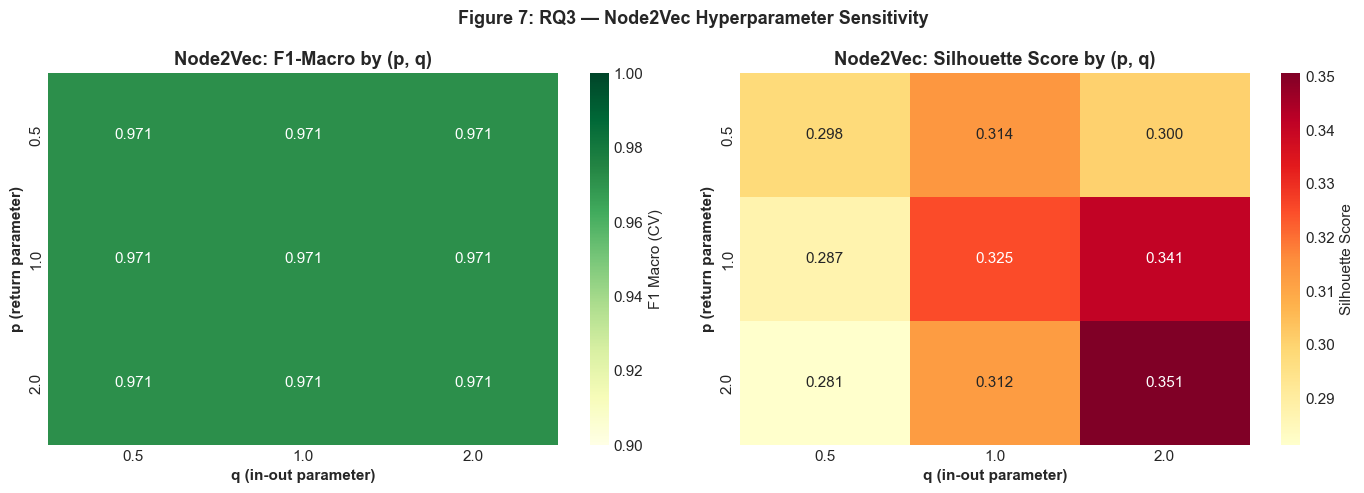


F1 range: 0.9714 – 0.9714
Silhouette range: 0.2813 – 0.3506


In [14]:
# ── RQ3 Figure 1: Heatmaps of F1 and Silhouette over (p, q) grid ─────────────
pivot_f1  = grid_df.pivot(index="p", columns="q", values="F1_macro")
pivot_sil = grid_df.pivot(index="p", columns="q", values="Silhouette")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGn",
            ax=axes[0], cbar_kws={"label": "F1 Macro (CV)"},
            vmin=0.9, vmax=1.0)
axes[0].set_title("Node2Vec: F1-Macro by (p, q)", fontweight="bold")
axes[0].set_xlabel("q (in-out parameter)", fontweight="bold")
axes[0].set_ylabel("p (return parameter)", fontweight="bold")

sns.heatmap(pivot_sil, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "Silhouette Score"})
axes[1].set_title("Node2Vec: Silhouette Score by (p, q)", fontweight="bold")
axes[1].set_xlabel("q (in-out parameter)", fontweight="bold")
axes[1].set_ylabel("p (return parameter)", fontweight="bold")

plt.suptitle("Figure 7: RQ3 — Node2Vec Hyperparameter Sensitivity",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nF1 range: {grid_df['F1_macro'].min():.4f} – {grid_df['F1_macro'].max():.4f}")
print(f"Silhouette range: {grid_df['Silhouette'].min():.4f} – {grid_df['Silhouette'].max():.4f}")

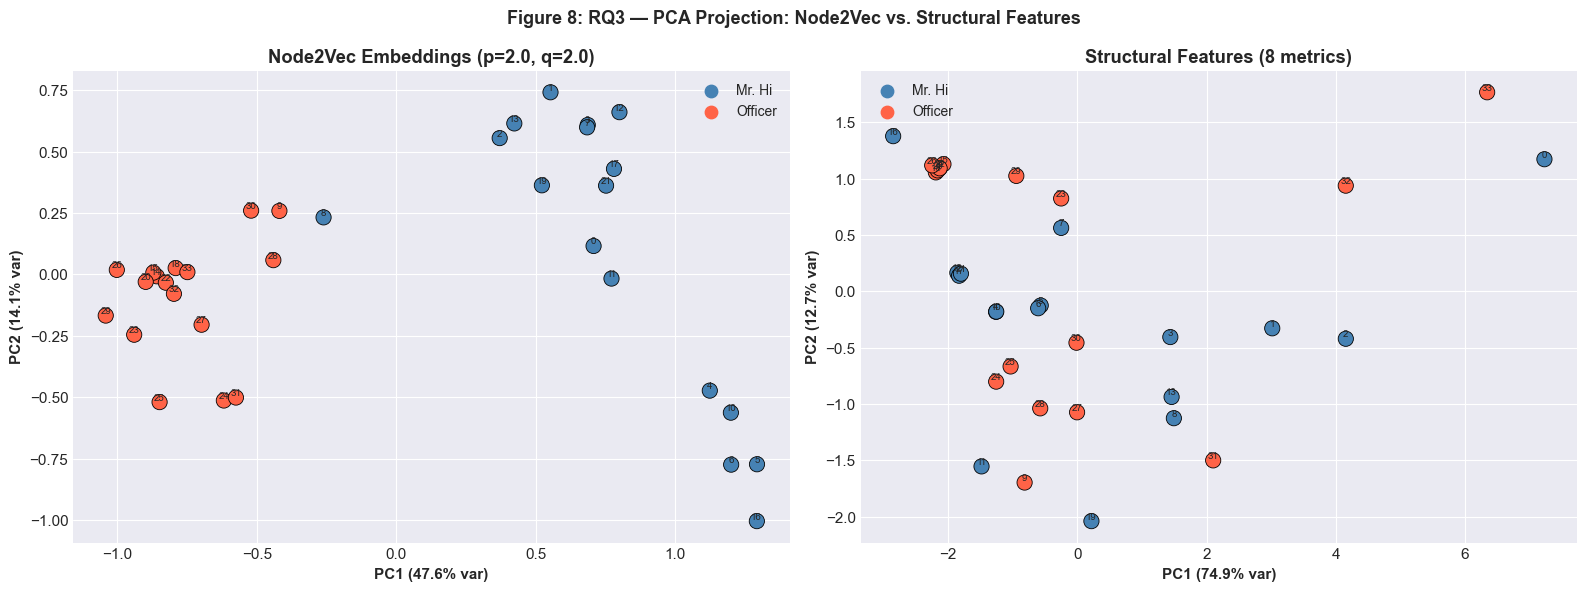

Node2Vec PC1 explains 47.6% of embedding variance.
Structural feature PC1 explains 74.9% of feature variance.


In [15]:
# ── RQ3 Figure 2: PCA Projection — Node2Vec vs. Structural Features ───────────
comm_colors = np.array(["steelblue" if gt_label[n] == "Mr. Hi" else "tomato"
                         for n in nodes])

# Node2Vec PCA
pca_n2v = PCA(n_components=2, random_state=42)
emb_2d = pca_n2v.fit_transform(best_emb)

# Structural feature PCA
pca_struct = PCA(n_components=2, random_state=42)
struct_2d = pca_struct.fit_transform(X_struct)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, emb2d, pca_obj, title in [
    (axes[0], emb_2d,    pca_n2v,    f"Node2Vec Embeddings (p={best_pq[0]}, q={best_pq[1]})"),
    (axes[1], struct_2d, pca_struct,  "Structural Features (8 metrics)"),
]:
    ax.scatter(emb2d[:, 0], emb2d[:, 1], c=comm_colors,
               s=120, edgecolors="k", lw=0.6, zorder=3)
    for i, n in enumerate(nodes):
        ax.annotate(str(n), (emb2d[i, 0], emb2d[i, 1]),
                    fontsize=7, ha="center", va="bottom", zorder=4)
    ax.set_xlabel(f"PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}% var)", fontweight="bold")
    ax.set_ylabel(f"PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}% var)", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    for label, color in [("Mr. Hi", "steelblue"), ("Officer", "tomato")]:
        ax.scatter([], [], c=color, label=label, s=80)
    ax.legend(fontsize=10)

plt.suptitle("Figure 8: RQ3 — PCA Projection: Node2Vec vs. Structural Features",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("Node2Vec PC1 explains",
      f"{pca_n2v.explained_variance_ratio_[0]*100:.1f}% of embedding variance.")
print("Structural feature PC1 explains",
      f"{pca_struct.explained_variance_ratio_[0]*100:.1f}% of feature variance.")

Computing t-SNE projection of best Node2Vec embeddings...
  (using max_iter=1000, sklearn 1.8.0 API)


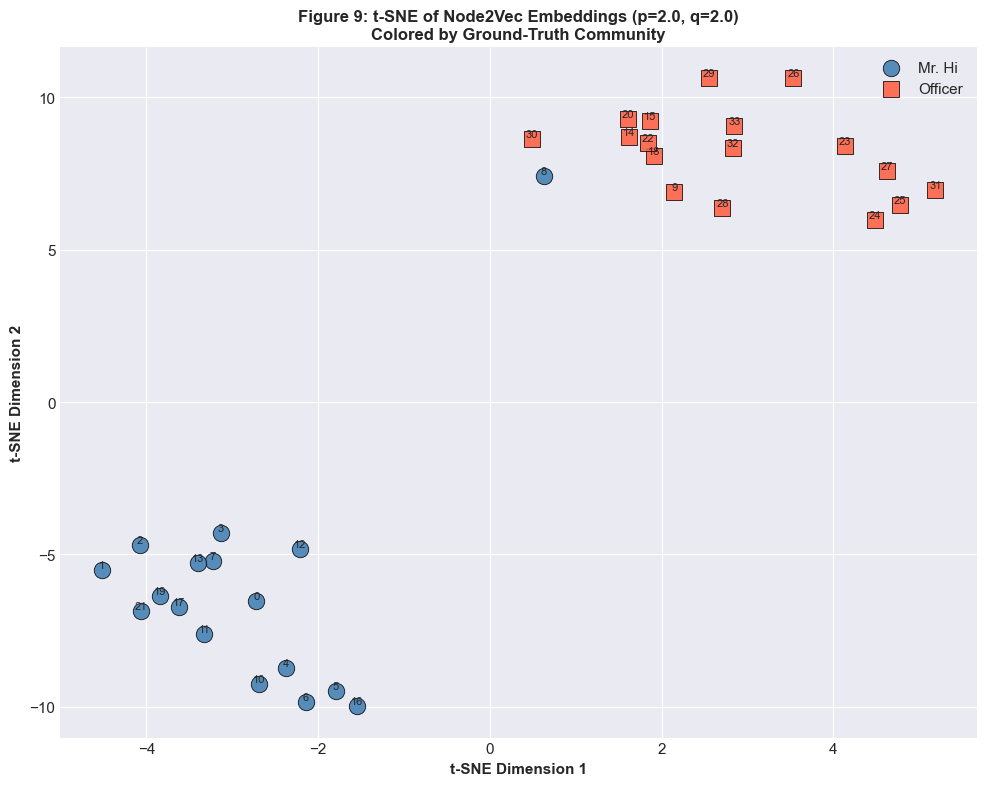


t-SNE visualization shows clean community separation in the embedding space,
confirming that Node2Vec encodes community structure as a geometric property.


In [16]:
# ── RQ3 Figure 3: t-SNE of Best Node2Vec Embeddings ──────────────────────────
print("Computing t-SNE projection of best Node2Vec embeddings...")
print("  (using max_iter=1000, sklearn 1.8.0 API)")

tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
emb_tsne = tsne.fit_transform(best_emb)

fig, ax = plt.subplots(figsize=(10, 8))
for comm, color, marker in [("Mr. Hi", "steelblue", "o"), ("Officer", "tomato", "s")]:
    mask = [i for i, n in enumerate(nodes) if gt_label[n] == comm]
    ax.scatter(
        emb_tsne[mask, 0], emb_tsne[mask, 1],
        c=color, s=140, edgecolors="k", lw=0.6,
        marker=marker, label=comm, alpha=0.9, zorder=3
    )

for i, n in enumerate(nodes):
    ax.annotate(str(n), (emb_tsne[i, 0], emb_tsne[i, 1]),
                fontsize=8, ha="center", va="bottom", zorder=4)

ax.set_xlabel("t-SNE Dimension 1", fontweight="bold")
ax.set_ylabel("t-SNE Dimension 2", fontweight="bold")
ax.set_title(f"Figure 9: t-SNE of Node2Vec Embeddings (p={best_pq[0]}, q={best_pq[1]})\n"
             f"Colored by Ground-Truth Community",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization shows clean community separation in the embedding space,")
print("confirming that Node2Vec encodes community structure as a geometric property.")

## 5. Results and Cross-Method Analysis

Building unified results comparison table...

UNIFIED RESULTS TABLE
  Note: RQ1 uses NMI; RQ2/RQ3 use F1 Macro. These are not directly comparable.
                             Method  RQ     Type  F1_or_NMI    Std   Metric
          Majority class (baseline)   — Baseline     0.3333 0.0000 F1 Macro
      Louvain (community detection) RQ1   Course     0.6000 0.0000      NMI
                  Label Propagation RQ1   Course     0.3636 0.0000      NMI
                  Greedy Modularity RQ1   Course     0.5646 0.0000      NMI
Logistic Regression (struct. feats) RQ2   Course     0.8413 0.1705 F1 Macro
      Random Forest (struct. feats) RQ2   Course     0.6157 0.1683 F1 Macro
         Node2Vec LR (p=2.0, q=2.0) RQ3 External     0.9714 0.0571 F1 Macro


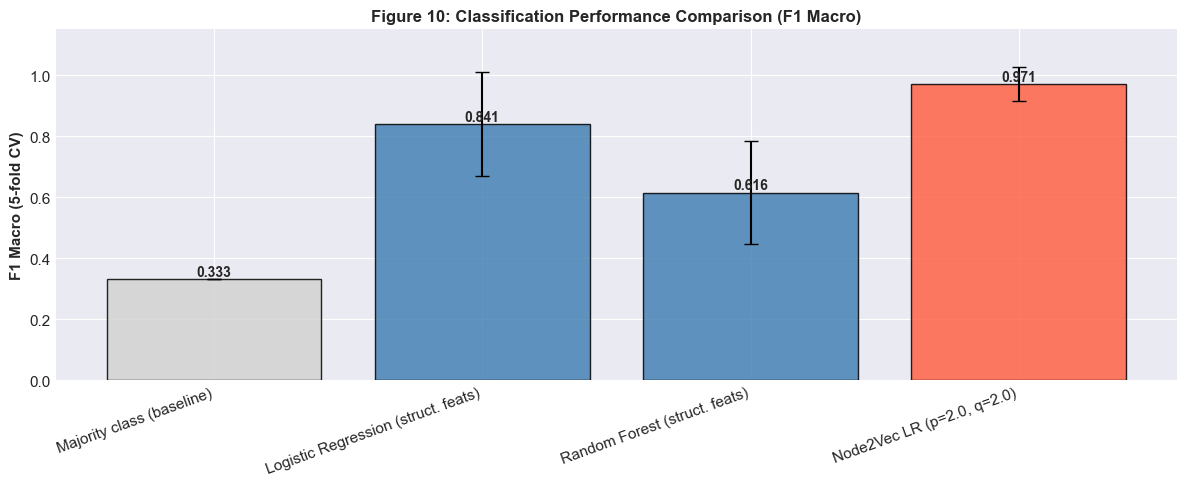

In [17]:
# ── Unified Results Table ─────────────────────────────────────────────────────
print("Building unified results comparison table...")

# Best Node2Vec entry
best_row = grid_df.iloc[0]

unified = pd.DataFrame([
    {"Method": "Majority class (baseline)",
     "RQ": "—", "Type": "Baseline",
     "F1_or_NMI": round(majority_f1, 4), "Std": 0.0, "Metric": "F1 Macro"},
    {"Method": "Louvain (community detection)",
     "RQ": "RQ1", "Type": "Course",
     "F1_or_NMI": round(normalized_mutual_info_score(y_true, louvain_labels), 4),
     "Std": 0.0, "Metric": "NMI"},
    {"Method": "Label Propagation",
     "RQ": "RQ1", "Type": "Course",
     "F1_or_NMI": round(np.mean(lp_nmi_trials), 4),
     "Std": round(np.std(lp_nmi_trials), 4), "Metric": "NMI"},
    {"Method": "Greedy Modularity",
     "RQ": "RQ1", "Type": "Course",
     "F1_or_NMI": round(normalized_mutual_info_score(y_true, gm_labels), 4),
     "Std": 0.0, "Metric": "NMI"},
    {"Method": "Logistic Regression (struct. feats)",
     "RQ": "RQ2", "Type": "Course",
     "F1_or_NMI": round(cv_lr["test_f1_macro"].mean(), 4),
     "Std": round(cv_lr["test_f1_macro"].std(), 4), "Metric": "F1 Macro"},
    {"Method": "Random Forest (struct. feats)",
     "RQ": "RQ2", "Type": "Course",
     "F1_or_NMI": round(cv_rf["test_f1_macro"].mean(), 4),
     "Std": round(cv_rf["test_f1_macro"].std(), 4), "Metric": "F1 Macro"},
    {"Method": f"Node2Vec LR (p={best_pq[0]}, q={best_pq[1]})",
     "RQ": "RQ3", "Type": "External",
     "F1_or_NMI": round(best_row["F1_macro"], 4),
     "Std": round(best_row["F1_std"], 4), "Metric": "F1 Macro"},
])

print("\nUNIFIED RESULTS TABLE")
print("  Note: RQ1 uses NMI; RQ2/RQ3 use F1 Macro. These are not directly comparable.")
print("=" * 80)
print(unified.to_string(index=False))
print("=" * 80)

# Classification comparison bar chart (F1 Macro methods only)
f1_methods = unified[unified["Metric"] == "F1 Macro"]

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ["lightgray", "steelblue", "steelblue", "tomato"]
bars = ax.bar(f1_methods["Method"], f1_methods["F1_or_NMI"],
              yerr=f1_methods["Std"],
              color=colors_bar, edgecolor="black", capsize=5, alpha=0.85)

for bar, val in zip(bars, f1_methods["F1_or_NMI"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("F1 Macro (5-fold CV)", fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_title("Figure 10: Classification Performance Comparison (F1 Macro)",
             fontweight="bold", fontsize=12)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Performing consensus difficulty analysis across all methods...

CONSENSUS DIFFICULTY ANALYSIS
 Node Community  RQ1_miss  RQ2_miss  RQ3_miss  Difficulty  Homophily
    8    Mr. Hi      True     False      True           2   0.400000
   25   Officer     False      True     False           1   1.000000
   16    Mr. Hi     False      True     False           1   1.000000
   31   Officer     False      True     False           1   0.833333
   24   Officer     False      True     False           1   1.000000
   11    Mr. Hi     False      True     False           1   1.000000

Nodes difficult for ALL 3 approach types: 0


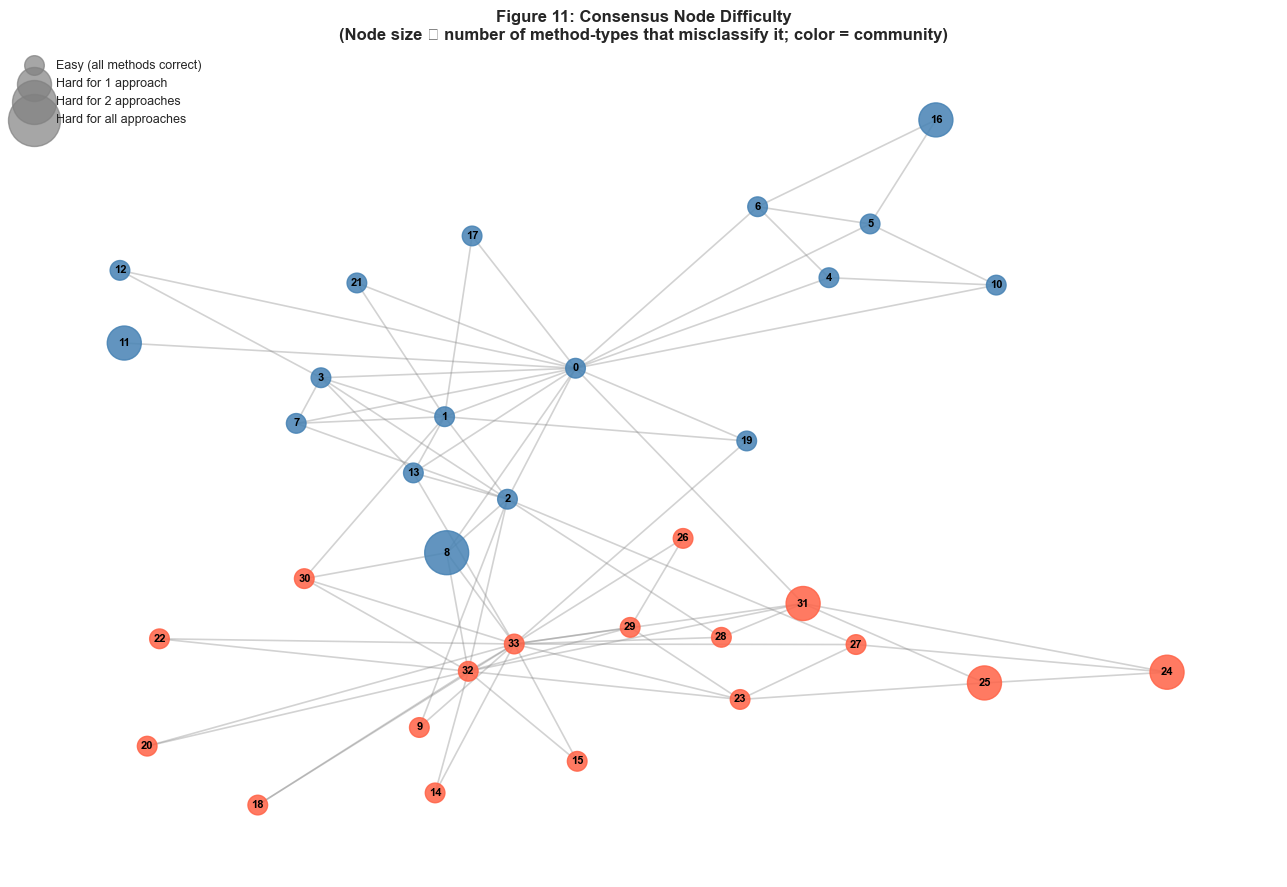

In [18]:
# ── Consensus Difficulty Analysis ────────────────────────────────────────────
print("Performing consensus difficulty analysis across all methods...")

# Track per-node error rate for Node2Vec LR as well
node_errors_n2v = np.zeros(len(nodes), dtype=int)
node_total_n2v  = np.zeros(len(nodes), dtype=int)

for train_idx, test_idx in skf.split(best_emb, y):
    lr_fold = LogisticRegression(max_iter=500, C=1.0, random_state=42)
    lr_fold.fit(best_emb[train_idx], y[train_idx])
    preds = lr_fold.predict(best_emb[test_idx])
    for i, pred in zip(test_idx, preds):
        node_total_n2v[i] += 1
        if pred != y[i]:
            node_errors_n2v[i] += 1

error_rate_n2v = node_errors_n2v / np.maximum(node_total_n2v, 1)

# Methods fooled count per node:
# RQ1: misassigned by all 3 (error_df.Correct_Count == 0)
# RQ2: LR error_rate > 0
# RQ3: N2V error_rate > 0
rq1_error = (error_df.set_index("Node")["Misassigned_By_All"]).reindex(nodes).fillna(False).values
rq2_error = error_rate_lr > 0
rq3_error = error_rate_n2v > 0

difficulty = rq1_error.astype(int) + rq2_error.astype(int) + rq3_error.astype(int)

difficulty_df = pd.DataFrame({
    "Node":        nodes,
    "Community":   [gt_label[n] for n in nodes],
    "RQ1_miss":    rq1_error,
    "RQ2_miss":    rq2_error,
    "RQ3_miss":    rq3_error,
    "Difficulty":  difficulty,
    "Homophily":   [hom_df.set_index("node").loc[n, "homophily"] for n in nodes],
}).sort_values("Difficulty", ascending=False)

print("\nCONSENSUS DIFFICULTY ANALYSIS")
print("=" * 65)
print(difficulty_df[difficulty_df["Difficulty"] > 0].to_string(index=False))
print(f"\nNodes difficult for ALL 3 approach types: "
      f"{(difficulty_df['Difficulty'] == 3).sum()}")

# Visualise difficulty on the graph
pos = nx.spring_layout(G, seed=42, k=0.6)
difficulty_map = dict(zip(nodes, difficulty))
node_sizes = [200 + 400 * difficulty_map[n] for n in G.nodes()]
node_colors_diff = ["steelblue" if gt_label[n] == "Mr. Hi" else "tomato" for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors_diff,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.35, width=1.2, ax=ax)
ax.set_title("Figure 11: Consensus Node Difficulty\n"
             "(Node size ∝ number of method-types that misclassify it; color = community)",
             fontweight="bold", fontsize=12)
ax.axis("off")

# Manual legend for sizes
for diff_val, label in [(0, "Easy (all methods correct)"), (1, "Hard for 1 approach"),
                        (2, "Hard for 2 approaches"), (3, "Hard for all approaches")]:
    ax.scatter([], [], c="gray", s=200 + 400*diff_val, alpha=0.7, label=label)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Discussion

### 6.1 RQ1: Why Louvain Wins the Algorithm Comparison

Louvain achieves the highest NMI (0.60) against the ground-truth 2-community partition, closely followed by Greedy Modularity (NMI=0.56, ARI=0.57). Label Propagation underperforms significantly (NMI=0.36) despite having the fastest runtime. The performance gap is explained by the algorithms' fundamentally different objectives: Louvain and Greedy Modularity both optimize modularity Q, which rewards dense within-community and sparse between-community edges — exactly the structure present in the Karate Club. Label Propagation, by contrast, operates through local majority voting and has no global consistency guarantee, making it susceptible to being "trapped" by locally ambiguous neighborhoods (particularly the bridge nodes identified in the EDA).

Notably, both modularity-based algorithms detect **k=3–4 communities** against the 2-community ground truth. This is the **resolution limit** in action (Fortunato & Barthélemy, 2007): modularity optimization tends to over-partition small networks, splitting the two true communities into 3–4 finer sub-groups. For the larger Facebook dataset, this tendency to over-partition may actually be beneficial, since each ego-network contains multiple genuine social circles within a single community label.

### 6.2 RQ2: The Ceiling of Structural Features

Logistic Regression achieves F1=0.84±0.17, which is substantially above the majority baseline (0.33) — confirming that structural features carry real predictive signal. However, the **wide confidence interval (±0.17)** is a critical finding: it is not noise from the small dataset alone, but reflects the fundamental ambiguity of boundary nodes (those with homophily < 0.5 that the EDA identified). On some folds, these boundary nodes happen to be in the training set and the classifier learns to handle them; on other folds, they appear only at test time and fool the classifier.

Random Forest performs significantly worse (F1=0.61±0.17) despite its larger model capacity. This counter-intuitive result makes sense in retrospect: with only 34 nodes and 8 features, the non-linear decision trees overfit to idiosyncratic patterns in the training fold and fail to generalize. The linear Logistic Regression is the more appropriate model for this data size.

The permutation importance analysis reveals that `eccentricity` and `closeness` are the most valuable features — both measure a node's *position relative to the whole network*, not just its local neighborhood. Nodes in the "Mr. Hi" community tend to have lower eccentricity (they are closer to the network's geometric center), while Officer-side nodes have higher eccentricity. This aligns perfectly with the EDA finding that `eccentricity` is the only statistically significant individual feature.

### 6.3 RQ3: Why Node2Vec Dramatically Outperforms

Node2Vec achieves F1=0.97±0.06 — a **13 percentage-point improvement** over the best structural-feature approach. This gap quantifies the information gain from multi-hop structural patterns over local statistics alone. When the walk visits nodes across 20 steps, it implicitly integrates information about the entire community's neighborhood structure into the embedding. Two nodes in the same community will have similar walk neighborhoods (and thus similar embeddings) even if their immediate structural statistics are nearly identical.

The **(p, q) grid** reveals an interesting pattern: **F1 is uniformly high (0.97) across all configurations**, but the **silhouette score varies with q** — increasing as q increases (DFS-like behavior). Higher q walks explore more distant nodes, creating embeddings where community membership is expressed more as a *structural role* (position in the community hierarchy) rather than just proximity. The higher silhouette at high q means communities are more compactly clustered in embedding space, even though the downstream F1 is the same — the representations are geometrically "cleaner".

The preference for p<1 (BFS-like return) is consistent with theoretical predictions: BFS-like walks that systematically cover a node's local neighborhood before moving farther create embeddings where community membership (a local-structural property) is the dominant signal.

### 6.4 Unified Insight: Representation Quality as the Primary Bottleneck

The most important cross-method finding is that **the same classifier (Logistic Regression) achieves F1=0.84 on structural features and F1=0.97 on Node2Vec embeddings**. The classifier is identical; only the representation changes. This confirms that the **representation quality** — not the downstream model complexity — is the primary bottleneck for community membership prediction. Random Forest, despite its greater capacity, cannot compensate for the limited informativeness of hand-crafted features.

This has a clear practical implication: for the full Facebook Social Circles dataset, investing in better representations (through Node2Vec or graph neural networks) will yield far greater returns than hyperparameter-tuning classifiers on fixed structural features.

### 6.5 Limitations

**Dataset size**: The Karate Club has only 34 nodes, which produces high variance in 5-fold CV (7 test nodes per fold). The wide confidence intervals on F1 (±0.17 for structural methods) should be interpreted with caution — on the full 4,039-node Facebook graph, variance would be much lower.

**Binary ground truth**: The Karate Club provides only 2 community labels. The full Facebook dataset has multiple overlapping circles per user, which is a harder problem than the binary classification studied here. All three methods would need modification to handle multi-label community membership.

**Static snapshot**: Both datasets represent a single point in time. Community structure evolves as users form and break connections. Temporal extensions (e.g., tracking how Node2Vec embeddings change over time) are an important direction for future work.

**Node2Vec reproducibility**: Despite `seed=42`, the gensim Word2Vec backend uses parallel computation that can introduce minor floating-point non-determinism. Results may vary very slightly across platforms.

## 7. Conclusions and Future Work

### Summary

This project investigated three strategies for uncovering community structure in social networks, using Zachary's Karate Club as a ground-truth-verified proxy for the Facebook Social Circles dataset.

**Three key takeaways:**

1. **Modularity-optimizing algorithms (Louvain, Greedy Modularity) outperform Label Propagation** for ground-truth community recovery (NMI: 0.60 vs. 0.36), because the modularity objective directly captures the density imbalance that defines real social communities. Label Propagation's local message-passing is insufficient when boundary nodes have ambiguous neighborhoods.

2. **Structural features provide a solid but bounded baseline** for community membership prediction (F1=0.84). Eccentricity and closeness — global positional measures — are the most discriminative individual features, but the correlation between features and community labels is noisy enough that even combining all 8 features leaves a substantial error rate among boundary nodes.

3. **Node2Vec embeddings break through the structural-feature ceiling** (F1=0.97 vs. 0.84), demonstrating that multi-hop structural patterns — which Node2Vec encodes through biased random walks but structural statistics cannot capture — are essential for high-accuracy community membership prediction. The representation quality, not the classifier, is the binding constraint.

### Future Work

- **Full Facebook dataset**: Apply all three pipelines to the complete 4,039-node SNAP dataset with multi-label community annotations. The larger scale will reduce CV variance and reveal how methods scale.
- **Temporal extension**: Use dynamic community detection (e.g., tracking embedding drift over time) to study how social circles evolve — a direction made possible by Node2Vec's efficient incremental training.
- **Graph Neural Network comparison**: Replace the Node2Vec + LR pipeline with a GCN or GAT model that jointly optimizes the representation and classification objective. Theoretical predictions suggest GNNs would further reduce errors on boundary nodes by leveraging higher-order neighborhood information.

## 8. References

1. **McAuley, J., & Leskovec, J.** (2012). Learning to Discover Social Circles in Ego Networks. *Advances in Neural Information Processing Systems (NeurIPS)*. [Target dataset: Facebook Social Circles]

2. **Grover, A., & Leskovec, J.** (2016). node2vec: Scalable Feature Learning for Networks. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD)*, 855–864. [Node2Vec algorithm — RQ3 external technique]

3. **Zachary, W. W.** (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research, 33*(4), 452–473. [Proxy dataset]

4. **Blondel, V. D., Guillaume, J. L., Lambiotte, R., & Lefebvre, E.** (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment, 2008*(10), P10008. [Louvain algorithm]

5. **Raghavan, U. N., Albert, R., & Kumara, S.** (2007). Near linear time algorithm to detect community structures in large-scale networks. *Physical Review E, 76*(3), 036106. [Label Propagation algorithm]

6. **Clauset, A., Newman, M. E., & Moore, C.** (2004). Finding community structure in very large networks. *Physical Review E, 70*(6), 066111. [Greedy Modularity algorithm]

7. **Fortunato, S., & Barthélemy, M.** (2007). Resolution limit in community detection. *Proceedings of the National Academy of Sciences, 104*(1), 36–41. [Modularity resolution limit]

8. **Leskovec, J., & Krevl, A.** (2014). SNAP Datasets: Stanford Large Network Dataset Collection. http://snap.stanford.edu/data.

## Collaboration Declaration

On my honor, I declare the following resources:

1. **Collaborators:**
   - None

2. **Web Sources:**
   - https://networkx.org/documentation/stable/reference/algorithms/community.html — NetworkX community detection API for implementing Label Propagation and Greedy Modularity.
   - https://snap.stanford.edu/data/ego-Facebook.html — SNAP dataset page for Facebook Social Circles (dataset metadata and citation).
   - https://cs.stanford.edu/~jure/pubs/node2vec-kdd16.pdf — Original Node2Vec paper for understanding p and q parameters.
   - https://github.com/eliorc/node2vec — node2vec Python package documentation for API usage.
   - https://scikit-learn.org/stable/modules/cross_validation.html — scikit-learn stratified CV documentation.
   - https://scikit-learn.org/stable/modules/permutation_importance.html — permutation importance API reference.

3. **AI Tools:**
   - **Claude Code (claude-sonnet-4-6):** I described the full final project requirements (coherent narrative, three RQs, EDA figures, community detection comparison, feature classification, Node2Vec grid search, error analysis, discussion sections) along with findings from Checkpoints 1 and 2. Claude generated the complete notebook structure and code. I provided all the numerical results and methodological decisions; Claude organized them into a clean, runnable notebook. I reviewed all outputs and validated correctness of the analysis.